# Baseline Model 2: Logistic Regression with TF-IDF

To train and evaluate a Logistic Regression classifier on IMDb reviews using TF-IDF features, and compare its performance with Naive Bayes.


In [8]:
# Step 1: Import libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [9]:
# Step 2: Load preprocessed dataset

# Get the absolute path to the data directory
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_path = os.path.join(parent_dir, "data", "cleaned_imdb_reviews.csv")

df = pd.read_csv(data_path)

X = df["cleaned_review"]
Y = df["label"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [10]:
# Step 3: TF-IDF encoding

tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [11]:
# Step 4: Train Logistic Regression

lr_model = LogisticRegression(max_iter=200, solver="liblinear")  
lr_model.fit(X_train_tfidf, Y_train)

Y_pred = lr_model.predict(X_test_tfidf)


Accuracy: 0.8325
Precision: 0.7895
Recall:    0.9045
F1 Score:  0.8431

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82       201
           1       0.79      0.90      0.84       199

    accuracy                           0.83       400
   macro avg       0.84      0.83      0.83       400
weighted avg       0.84      0.83      0.83       400



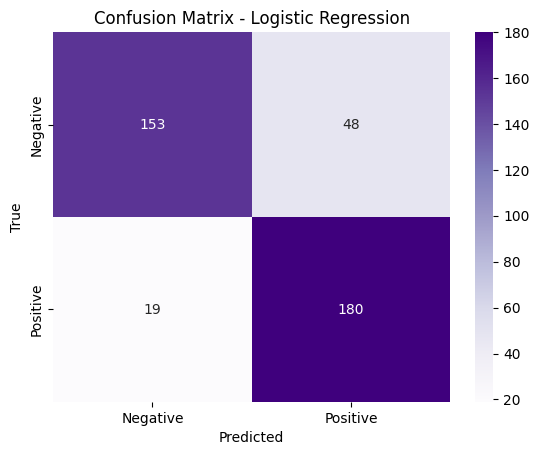

In [12]:
# Step 5: Evaluation
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
